In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/customer_churn.csv')

print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)
df.head()

Shape: (7043, 21)

Column names:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [3]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [4]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [5]:
# Check missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
# Check duplicates
df.duplicated().sum()

np.int64(0)

In [7]:
# Try converting TotalCharges to numeric, see what fails
pd.to_numeric(df['TotalCharges'], errors='coerce').isnull().sum()

np.int64(11)

In [12]:
df[pd.to_numeric(df['TotalCharges'], errors='coerce').isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [10]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [11]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [13]:
df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [14]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [15]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [16]:
df['TotalCharges'].dtype

dtype('float64')

In [17]:
df = df.drop('customerID', axis=1)

In [18]:
df.shape

(7043, 20)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


C:\Users\ARUNVEL\AppData\Local\Temp\ipykernel_25236\3348741284.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette=['#2ecc71', '#e74c3c'])


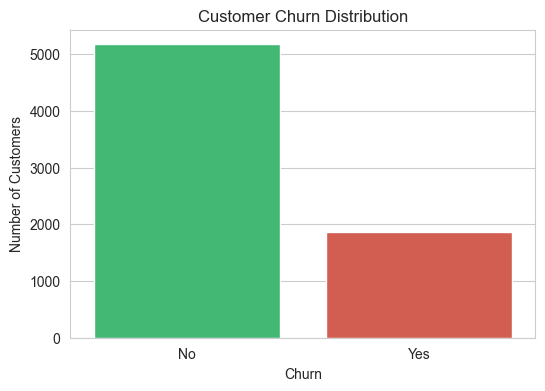

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

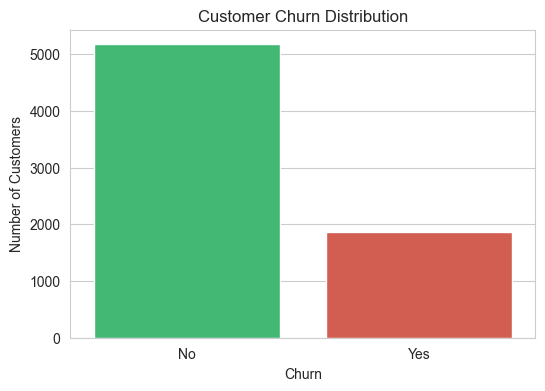

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn', hue='Churn', palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

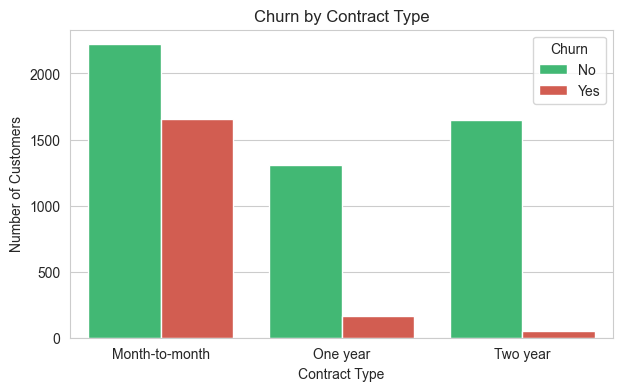

In [23]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='Contract', hue='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.show()

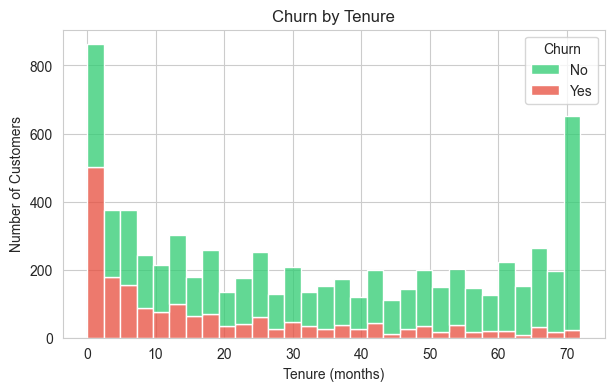

In [24]:
plt.figure(figsize=(7,4))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', palette=['#2ecc71', '#e74c3c'], bins=30)
plt.title('Churn by Tenure')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')
plt.show()

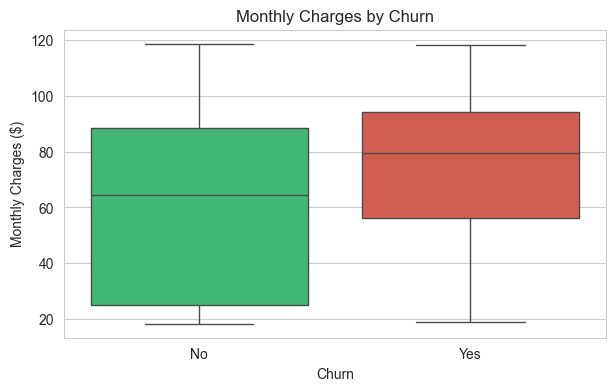

In [25]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn', palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title('Monthly Charges by Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges ($)')
plt.show()

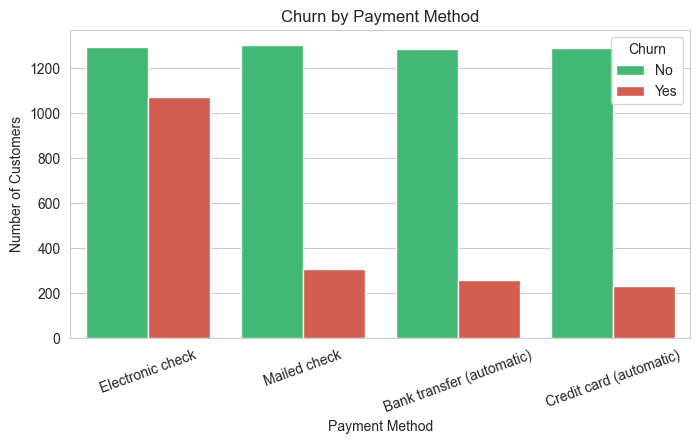

In [26]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='PaymentMethod', hue='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Churn by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.xticks(rotation=20)
plt.legend(title='Churn')
plt.show()

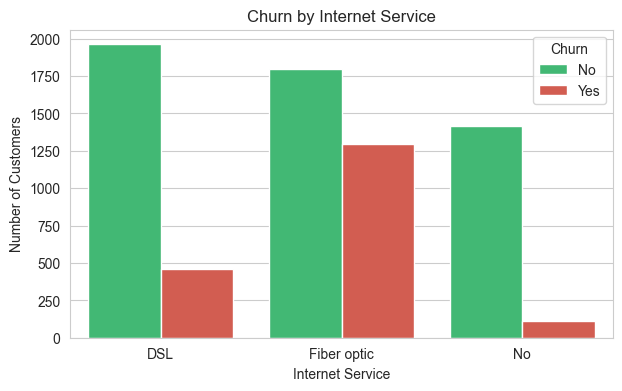

In [27]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='InternetService', hue='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Churn by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.show()

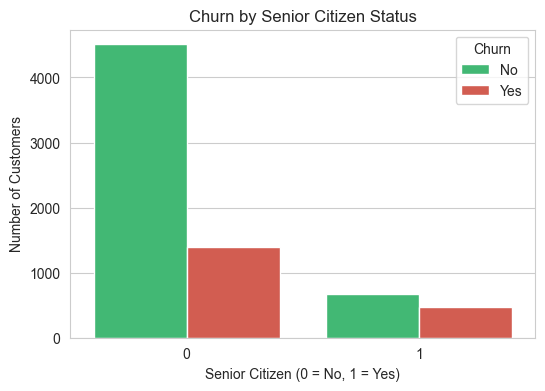

In [28]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='SeniorCitizen', hue='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Churn by Senior Citizen Status')
plt.xlabel('Senior Citizen (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.show()

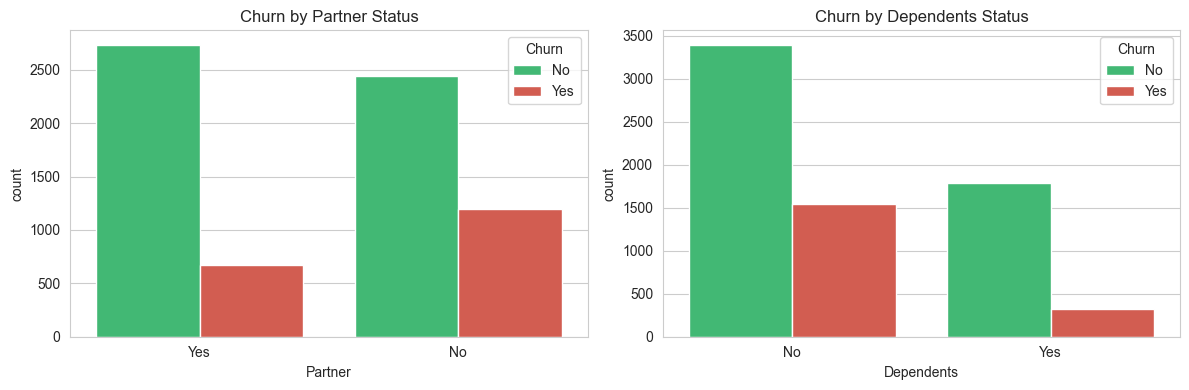

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.countplot(data=df, x='Partner', hue='Churn', palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Churn by Partner Status')
axes[0].legend(title='Churn')

sns.countplot(data=df, x='Dependents', hue='Churn', palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title('Churn by Dependents Status')
axes[1].legend(title='Churn')

plt.tight_layout()
plt.show()

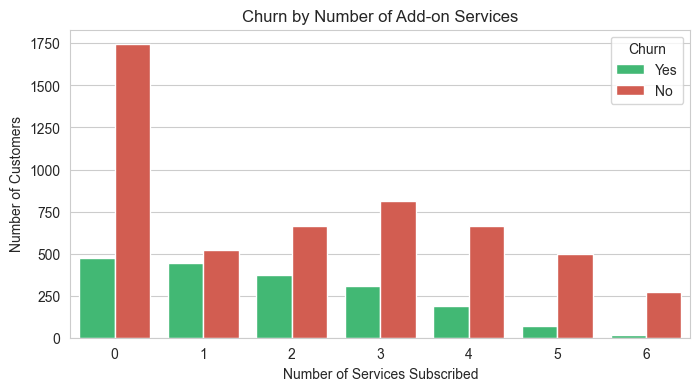

In [30]:
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

df['NumServices'] = (df[service_cols] == 'Yes').sum(axis=1)

plt.figure(figsize=(8,4))
sns.countplot(data=df, x='NumServices', hue='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Churn by Number of Add-on Services')
plt.xlabel('Number of Services Subscribed')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.show()

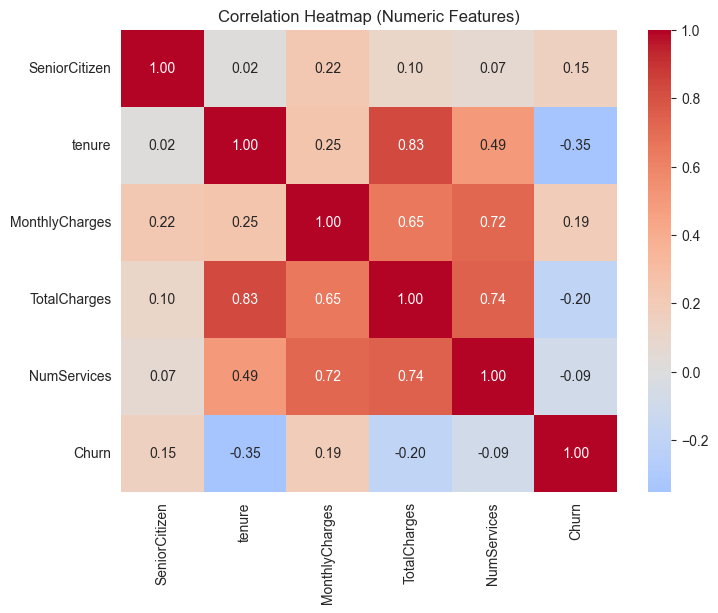

In [31]:
plt.figure(figsize=(8,6))
numeric_df = df[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'NumServices']].copy()
numeric_df['Churn'] = (df['Churn'] == 'Yes').astype(int)

corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Correlation Heatmap (Numeric Features)')
plt.show()

In [32]:
X = df.drop('Churn', axis=1)
y = (df['Churn'] == 'Yes').astype(int)

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'NumServices', 'SeniorCitizen']
categorical_features = X.columns.difference(numeric_features).tolist()

print("Numeric features:", numeric_features)
print("\nCategorical features:", categorical_features)

Numeric features: ['tenure', 'MonthlyCharges', 'TotalCharges', 'NumServices', 'SeniorCitizen']

Categorical features: ['Contract', 'Dependents', 'DeviceProtection', 'InternetService', 'MultipleLines', 'OnlineBackup', 'OnlineSecurity', 'PaperlessBilling', 'Partner', 'PaymentMethod', 'PhoneService', 'StreamingMovies', 'StreamingTV', 'TechSupport', 'gender']


In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ]
)

In [34]:
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain churn rate:", y_train.mean())
print("Test churn rate:", y_test.mean())

Train shape: (5634, 20)
Test shape: (1409, 20)

Train churn rate: 0.2653532126375577
Test churn rate: 0.2654364797728886


In [36]:
from sklearn.linear_model import LogisticRegression

log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

log_reg_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [37]:
y_pred = log_reg_pipeline.predict(X_test)
y_pred_proba = log_reg_pipeline.predict_proba(X_test)[:, 1]

print("First 10 predictions:", y_pred[:10])
print("First 10 actual values:", y_test[:10].values)
print("First 10 churn probabilities:", y_pred_proba[:10].round(3))

First 10 predictions: [0 1 0 0 0 1 0 0 0 0]
First 10 actual values: [0 0 0 0 0 0 0 0 0 1]
First 10 churn probabilities: [0.046 0.683 0.06  0.399 0.022 0.602 0.446 0.128 0.003 0.397]


In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=6, random_state=42))
])
dt_pipeline.fit(X_train, y_train)

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42))
])
rf_pipeline.fit(X_train, y_train)

print("Decision Tree and Random Forest trained successfully")

Decision Tree and Random Forest trained successfully


In [39]:
dt_pred = dt_pipeline.predict(X_test)
dt_proba = dt_pipeline.predict_proba(X_test)[:, 1]

rf_pred = rf_pipeline.predict(X_test)
rf_proba = rf_pipeline.predict_proba(X_test)[:, 1]

print("Decision Tree - first 10 predictions:", dt_pred[:10])
print("Random Forest - first 10 predictions:", rf_pred[:10])

Decision Tree - first 10 predictions: [0 1 0 0 0 0 0 0 0 0]
Random Forest - first 10 predictions: [0 1 0 0 0 0 0 0 0 0]


In [40]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

models = {
    'Logistic Regression': (y_pred, y_pred_proba),
    'Decision Tree': (dt_pred, dt_proba),
    'Random Forest': (rf_pred, rf_proba)
}

results = []
for name, (pred, proba) in models.items():
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1-Score': f1_score(y_test, pred)
    })

comparison_df = pd.DataFrame(results)
comparison_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.806246,0.659306,0.558824,0.604920
1,Decision Tree,0.800568,0.666667,0.497326,0.569678
2,Random Forest,0.799148,0.654237,0.516043,0.576981


In [41]:
for name, (pred, proba) in models.items():
    print(f"\n{'='*50}")
    print(f"{name}")
    print('='*50)
    print(classification_report(y_test, pred, target_names=['No Churn', 'Churn']))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, pred))


Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.85      0.90      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

Confusion Matrix:
[[927 108]
 [165 209]]

Decision Tree
              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1035
       Churn       0.67      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409

Confusion Matrix:
[[942  93]
 [188 186]]

Random Forest
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.65      0.52      0.58       374

    accuracy                           0.80      

In [42]:
log_reg_bal = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])
log_reg_bal.fit(X_train, y_train)

dt_bal = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=6, random_state=42, class_weight='balanced'))
])
dt_bal.fit(X_train, y_train)

rf_bal = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced'))
])
rf_bal.fit(X_train, y_train)

print("Balanced models trained")

Balanced models trained


In [43]:
models_bal = {
    'Logistic Regression (balanced)': log_reg_bal.predict(X_test),
    'Decision Tree (balanced)': dt_bal.predict(X_test),
    'Random Forest (balanced)': rf_bal.predict(X_test)
}

results_bal = []
for name, pred in models_bal.items():
    results_bal.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1-Score': f1_score(y_test, pred)
    })

comparison_bal_df = pd.DataFrame(results_bal)
comparison_bal_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression (balanced),0.738112,0.504303,0.783422,0.613613
1,Decision Tree (balanced),0.738822,0.504934,0.820856,0.625255
2,Random Forest (balanced),0.760114,0.536290,0.711230,0.611494


In [44]:
feature_names = (numeric_features + 
                  list(dt_bal.named_steps['preprocessor']
                       .named_transformers_['cat']
                       .get_feature_names_out(categorical_features)))

importances = dt_bal.named_steps['classifier'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

importance_df.head(15)

,Feature,Importance
6,Contract_Two year,0.370657
5,Contract_One year,0.231805
0,tenure,0.107615
10,InternetService_Fiber optic,0.102030
2,TotalCharges,0.046198
1,MonthlyCharges,0.032483
25,StreamingMovies_Yes,0.031190
21,PaymentMethod_Electronic check,0.018860
14,OnlineBackup_No internet service,0.013932
23,PhoneService_Yes,0.010991


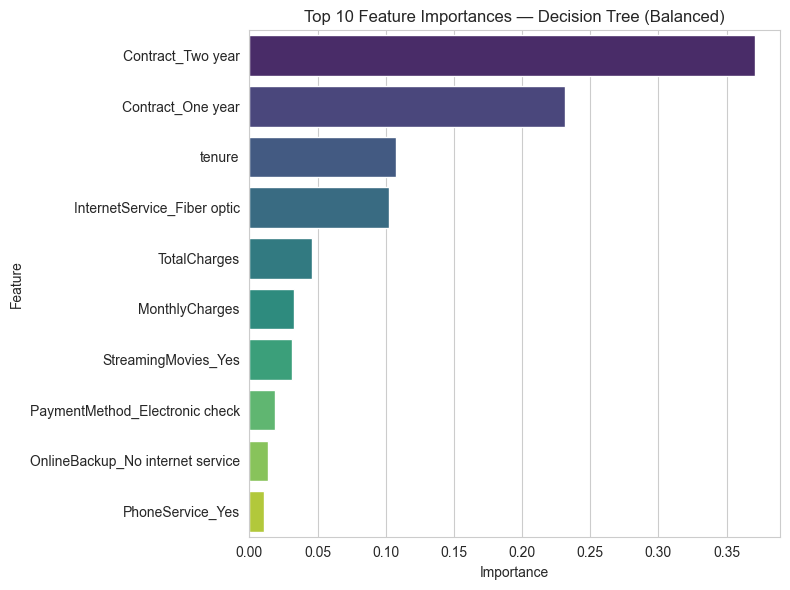

In [45]:
plt.figure(figsize=(8,6))
top_features = importance_df.head(10)
sns.barplot(data=top_features, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Top 10 Feature Importances — Decision Tree (Balanced)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [46]:
def predict_churn(customer_dict, model=dt_bal):
    customer_df = pd.DataFrame([customer_dict])
    
    prediction = model.predict(customer_df)[0]
    probability = model.predict_proba(customer_df)[0][1]
    
    result = "Churn" if prediction == 1 else "No Churn"
    
    print(f"Prediction: {result}")
    print(f"Churn Probability: {probability:.2%}")
    
    return prediction, probability

In [47]:
sample_customer = {
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'No',
    'Dependents': 'No',
    'tenure': 12,
    'PhoneService': 'Yes',
    'MultipleLines': 'No',
    'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'No',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'No',
    'StreamingMovies': 'No',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 75.0,
    'TotalCharges': 900.0,
    'NumServices': 0
}

predict_churn(sample_customer)

Prediction: Churn
Churn Probability: 74.62%


(np.int64(1), np.float64(0.7461581514687158))

In [48]:
import joblib

joblib.dump(dt_bal, '../models/churn_model.pkl')
print("Model saved successfully")

Model saved successfully
